# Housing Prices: My Improved Model

This notebook is my own extension of Kaggle's Housing Prices exercise. Instead of using only the starter feature list, I use the full training dataset, inspect numeric feature correlations, handle missing numeric values, and evaluate a Random Forest model on a validation split.

## Load the Data

I use the local `house_data.csv` file and separate the target column, `SalePrice`, from the features.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

home_data = pd.read_csv("house_data.csv")
home_data.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Create a Validation Split

To make better predictions and check that the model is working correctly, I split `home_data` into training and validation data.

In [2]:
X = home_data.drop(columns="SalePrice")
y = home_data["SalePrice"]

train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)
train_X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1095 entries, 6 to 1061
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1095 non-null   int64  
 1   MSSubClass     1095 non-null   int64  
 2   MSZoning       1095 non-null   object 
 3   LotFrontage    895 non-null    float64
 4   LotArea        1095 non-null   int64  
 5   Street         1095 non-null   object 
 6   Alley          67 non-null     object 
 7   LotShape       1095 non-null   object 
 8   LandContour    1095 non-null   object 
 9   Utilities      1095 non-null   object 
 10  LotConfig      1095 non-null   object 
 11  LandSlope      1095 non-null   object 
 12  Neighborhood   1095 non-null   object 
 13  Condition1     1095 non-null   object 
 14  Condition2     1095 non-null   object 
 15  BldgType       1095 non-null   object 
 16  HouseStyle     1095 non-null   object 
 17  OverallQual    1095 non-null   int64  
 18  OverallCond  

## Explore Numeric Correlations

Before modeling, I check which numeric features are most strongly related to `SalePrice`. This helps me understand what the model may find useful.

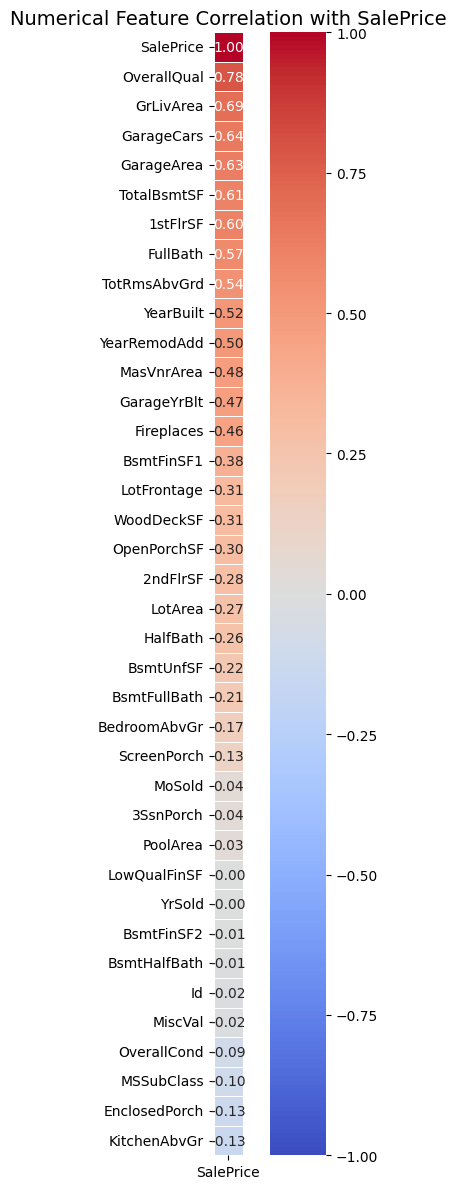

In [3]:
train_combined = train_X.copy()
train_combined["SalePrice"] = train_y

numerical_train = train_combined.select_dtypes(include=["int64", "float64"])
saleprice_corr = numerical_train.corr()[["SalePrice"]].sort_values(
    by="SalePrice", ascending=False
)

plt.figure(figsize=(6, 12))
sns.heatmap(
    saleprice_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True,
    vmax=1,
    vmin=-1,
)
plt.title("Numerical Feature Correlation with SalePrice", fontsize=14)
plt.tight_layout()
plt.show()

## Train a Baseline Random Forest

For this version, I keep only numeric columns and fill missing values with the median. This lets the Random Forest use many more features than the starter notebook without crashing on missing values or text columns.

In [4]:
numeric_train_X = train_X.select_dtypes(include=["int64", "float64"])
numeric_val_X = val_X.select_dtypes(include=["int64", "float64"])

imputer = SimpleImputer(strategy="median")
imputed_train_X = pd.DataFrame(
    imputer.fit_transform(numeric_train_X),
    columns=numeric_train_X.columns,
    index=numeric_train_X.index,
)
imputed_val_X = pd.DataFrame(
    imputer.transform(numeric_val_X),
    columns=numeric_val_X.columns,
    index=numeric_val_X.index,
)

rf_model = RandomForestRegressor(n_estimators=100, random_state=1)
rf_model.fit(imputed_train_X, train_y)

predictions = rf_model.predict(imputed_val_X)
mae_score = mean_absolute_error(val_y, predictions)
print(f"Validation MAE: ${mae_score:,.2f}")

Validation MAE: $16,925.12


## Feature Importance

Finally, I look at which numeric features the Random Forest used most heavily.

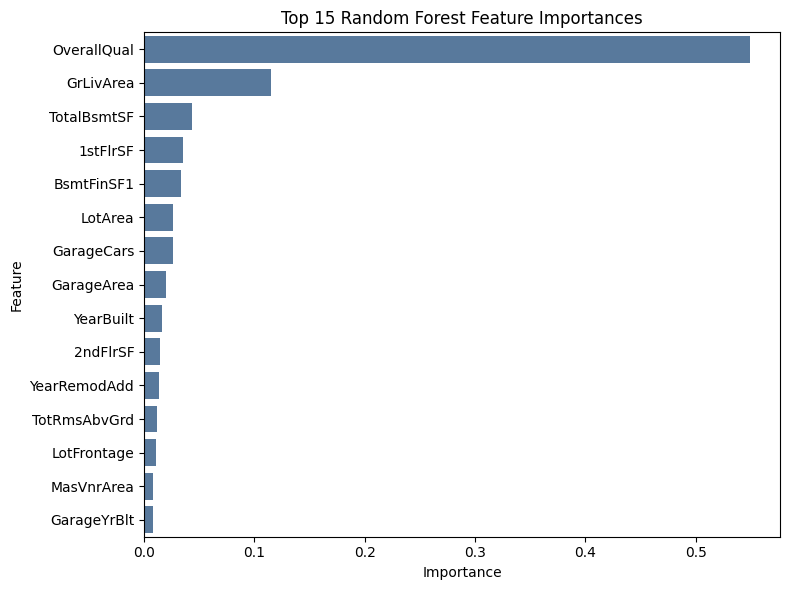

In [5]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=imputed_train_X.columns,
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
top_features = feature_importance.head(15)
sns.barplot(x=top_features.values, y=top_features.index, color="#4C78A8")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Random Forest with One-Hot Encoded Categories

The first model only used numeric columns. In this experiment, I also include categorical columns by filling missing values and converting text categories into numeric one-hot encoded columns. Then I train another Random Forest and compare the validation MAE.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

numeric_transformer = SimpleImputer(strategy="median")
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

categorical_rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(n_estimators=100, random_state=1)),
    ]
)

categorical_rf_model.fit(train_X, train_y)
categorical_predictions = categorical_rf_model.predict(val_X)
categorical_mae = mean_absolute_error(val_y, categorical_predictions)

print(f"Numeric-only Random Forest MAE: ${mae_score:,.2f}")
print(f"One-hot encoded Random Forest MAE: ${categorical_mae:,.2f}")
print(f"Difference: ${mae_score - categorical_mae:,.2f}")

Numeric-only Random Forest MAE: $16,925.12
One-hot encoded Random Forest MAE: $16,764.90
Difference: $160.22


A positive difference means the one-hot encoded model improved the validation MAE. 

In [7]:
from xgboost import XGBRegressor

xgboost_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                ]
            ),
            categorical_features,
        ),
    ]
)

xgboost_model = Pipeline(
    steps=[
        ("preprocessor", xgboost_preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=1,
                n_jobs=-1,
            ),
        ),
    ]
)

xgboost_model.fit(train_X, train_y)
xgboost_predictions = xgboost_model.predict(val_X)
xgboost_mae = mean_absolute_error(val_y, xgboost_predictions)

print(f"One-hot encoded Random Forest MAE: ${categorical_mae:,.2f}")
print(f"One-hot encoded XGBoost MAE: ${xgboost_mae:,.2f}")
print(f"Difference: ${categorical_mae - xgboost_mae:,.2f}")

One-hot encoded Random Forest MAE: $16,764.90
One-hot encoded XGBoost MAE: $14,329.02
Difference: $2,435.87


A positive difference means XGBoost improved over the one-hot encoded Random Forest. A negative difference means Random Forest performed better on this validation split.